# Italy 

This notebook focuses on the Italian spot market, analyzing PUN index and its relationship with renewable generation.

Data sources:
* GME (Gestore del Mercato Elettrico) for aggregated Italian PUN index;
* TERNA for load and generation data.

The analysis will be organized as follows:
1. Descriptive statistics
2. Univariate analysis (distribution shape)
3. Time series analysis
4. Correlation
5. Renewables


<u>Note</u>:  
The Italian day-ahead market is divided into seven bidding zones, each characterized by a potentially different zonal price. Market participants therefore settle transactions at the relevant zonal price rather than directly at the PUN index, which represents a weighted average of zonal prices.  
For the purposes of this research, the analysis focuses exclusively on the aggregated PUN index.

In [1]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
import plotly.graph_objects as go 

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'it_merged-dataset.csv')

In [2]:
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.00,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.00,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.00,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.00,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.00,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000
...,...,...,...,...,...,...,...,...,...,...,...,...
48055,2026-06-28 19:00:00,159.01250,0.56,7.50,1.85,3.359,21.10,0.98,31.99,0.340419,43487.25000,42911.50000
48056,2026-06-28 20:00:00,156.20537,0.56,8.77,0.19,2.801,21.92,0.73,32.17,0.318620,43231.00000,42299.00000
48057,2026-06-28 21:00:00,158.80250,0.56,8.43,0.00,2.858,22.61,0.58,32.18,0.297390,43050.25100,42659.74975
48058,2026-06-28 22:00:00,155.93208,0.56,7.76,0.00,2.790,22.60,0.53,31.45,0.281399,41414.99975,41477.75050


## 1. Descriptive Statistics

Descriptive statistics includes measures of central tendency, dispersion and distribution shape through the five years time span.

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48060 entries, 0 to 48059
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               48060 non-null  str    
 1   Prices             48060 non-null  float64
 2   Geothermal         48060 non-null  float64
 3   Hydro              48060 non-null  float64
 4   Photovoltaic       48060 non-null  float64
 5   Self-consumption   48060 non-null  float64
 6   Thermal            48060 non-null  float64
 7   Wind               48060 non-null  float64
 8   TOT Generation     48060 non-null  float64
 9   Renewables weight  48060 non-null  float64
 10  Total Load         48060 non-null  float64
 11  Load forecasted    48060 non-null  float64
dtypes: float64(11), str(1)
memory usage: 4.4 MB


In [4]:
# fix Date datatype
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data = data.dropna(subset=['Date'])
data = data.sort_values('Date').reset_index(drop=True)

In [6]:
data.describe()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
count,48060,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000,48060.000000
mean,2023-09-29 15:26:23.370786,153.596749,0.610154,4.721664,3.003705,3.687027,16.046669,2.506154,26.888346,0.404019,35695.678033,35879.727247
min,2021-01-01 00:00:00,0.000000,0.470000,0.610000,-0.010000,0.028000,3.990000,0.020000,11.110000,0.080460,17237.750000,17504.249500
25%,2022-05-16 18:45:00,99.554493,0.600000,2.770000,0.000000,2.449750,11.320000,1.020000,21.080000,0.288982,28645.687187,28859.937688
50%,2023-09-29 11:30:00,122.690475,0.610000,4.320000,0.100000,3.448000,15.470000,2.030000,26.530000,0.383955,35140.000625,35241.999500
75%,2025-02-11 04:15:00,170.540390,0.630000,6.330000,5.530000,4.628000,20.350000,3.660000,32.290000,0.499450,42470.625188,42683.812688
max,2026-06-28 23:00:00,870.000000,0.660000,14.470000,36.550000,24.815000,35.500000,9.020000,60.280000,0.849329,81964.999750,66441.249750
std,NaN,100.883778,0.022390,2.416861,4.292178,1.613660,6.120779,1.830623,7.088098,0.154189,8199.368070,8190.356574


From the descriptive statistics, it is evident that average electricity prices in Italy are relatively high. This is consistent with the fact that the Italian energy market is strongly influenced by natural gas prices, which still represent the dominant energy source, as also shown by the Thermal column, which reports the highest average electricity generation among all sources.  
This structure has been further affected by the Russian invasion of Ukraine and the subsequent disruption of Russian natural gas flows to Italy. As a result, both natural gas prices and market expectations (as reflected by the TTF index) increased significantly, contributing to higher electricity prices.

The actual Load and the forecasted Load display similar patterns across key descriptive statistics, suggesting a good overall alignment between observed and predicted energy consumption levels, although a more detailed error analysis would be required to fully assess predictive performance.

In [7]:
cols = ['Prices', 'Total Load', 'TOT Generation']

summary = []

for col in cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    std = data[col].std()
    mean = data[col].mean()

    summary.append({
        'variable': col,
        'mean': data[col].mean(),
        'median': data[col].median(),
        'min': data[col].min(),
        'max': data[col].max(),
        'Q1': q1,
        'Q3': q3,
        'std': std,
        'variance': data[col].var(),
        'range': data[col].max() - data[col].min(),
        'IQR': iqr,
        'RSD': std / mean
    })

summary_df = pd.DataFrame(summary)
summary_df

,variable,mean,median,min,max,Q1,Q3,std,variance,range,IQR,RSD
0,Prices,153.596749,122.690475,0.00,870.00000,99.554493,170.540390,100.883778,1.017754e+04,870.00000,70.985897,0.656809
1,Total Load,35695.678033,35140.000625,17237.75,81964.99975,28645.687187,42470.625188,8199.368070,6.722964e+07,64727.24975,13824.938000,0.229702
2,TOT Generation,26.888346,26.530000,11.11,60.28000,21.080000,32.290000,7.088098,5.024113e+01,49.17000,11.210000,0.263612


As indicated by the Relative Standard Deviation (RSD), defined as the standard deviation relative to the mean, load appears to be the most stable variable over time (22% variability relative to its mean), while prices and generation exhibit higher variability, at 67% and 80% respectively.

Electricity prices have shown notable instability, particularly since the beginning of the Russia–Ukraine war. However, generation displays even higher variability, which is consistent with the structure of the national energy mix. Renewable energy sources, mainly solar and wind, are gradually increasing their share and are inherently subject to weather-related fluctuations.

The higher relative variability observed for total generation and prices indicates substantial fluctuations on the supply and price sides of the electricity market, whereas load appears comparatively stable.

## 2. Distribution analysis

In [8]:
dist_summary = []

for col in cols:
    skewness = data[col].skew()
    kurtosis = data[col].kurt()

    dist_summary.append({
        'variable': col,
        'skewness': skewness,
        'kurtosis': kurtosis,
    })

dist_summary_df = pd.DataFrame(dist_summary)
dist_summary_df

,variable,skewness,kurtosis
0,Prices,2.399367,7.323070
1,Total Load,0.145259,-0.967264
2,TOT Generation,0.208240,-0.785019


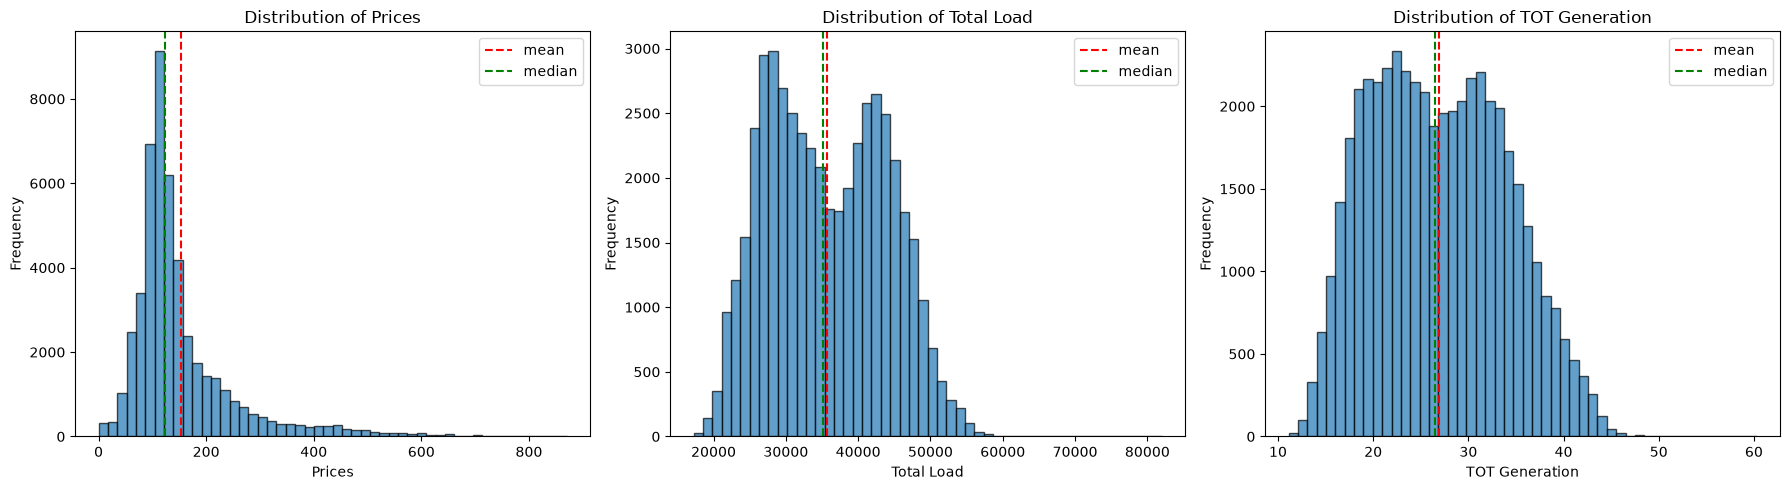

In [9]:
import matplotlib.pyplot as plt

#create plot
fig, axes = plt.subplots(1, len(cols), figsize=(18, 5))

for i, col in enumerate(cols):
    axes[i].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(data[col].mean(), color='red', linestyle='--', label='mean')
    axes[i].axvline(data[col].median(), color='green', linestyle='--', label='median')
    axes[i].legend()

plt.tight_layout()
plt.show()

From the previous results, electricity prices exhibit a pronounced right-skewed and heavy-tailed distribution, consistent with the occurence of occasional price spikes. Load and total generation display substantially more symmetric distributions.  
The descriptive statistics and histograms indicate substantial deviations from normality, particularly for electricity prices.

In more datails:
* Prices' skewness at 2.29 and kurtosis at 6.5 confirm a shock-driven market as it is asymetric with intense spikes.
* Load is almost symetric, but has negative kurtosis, indicating a stable variable.
* Generation is characterized by low skew (0.18) indicating a stable variable.

## 3. Time series analysis

In this section, since the project aim to analyze the relationship between Prices, Load and Generation, time series evolution of those variables are displayed during the five-years time span.

### 3.1. Raw time series

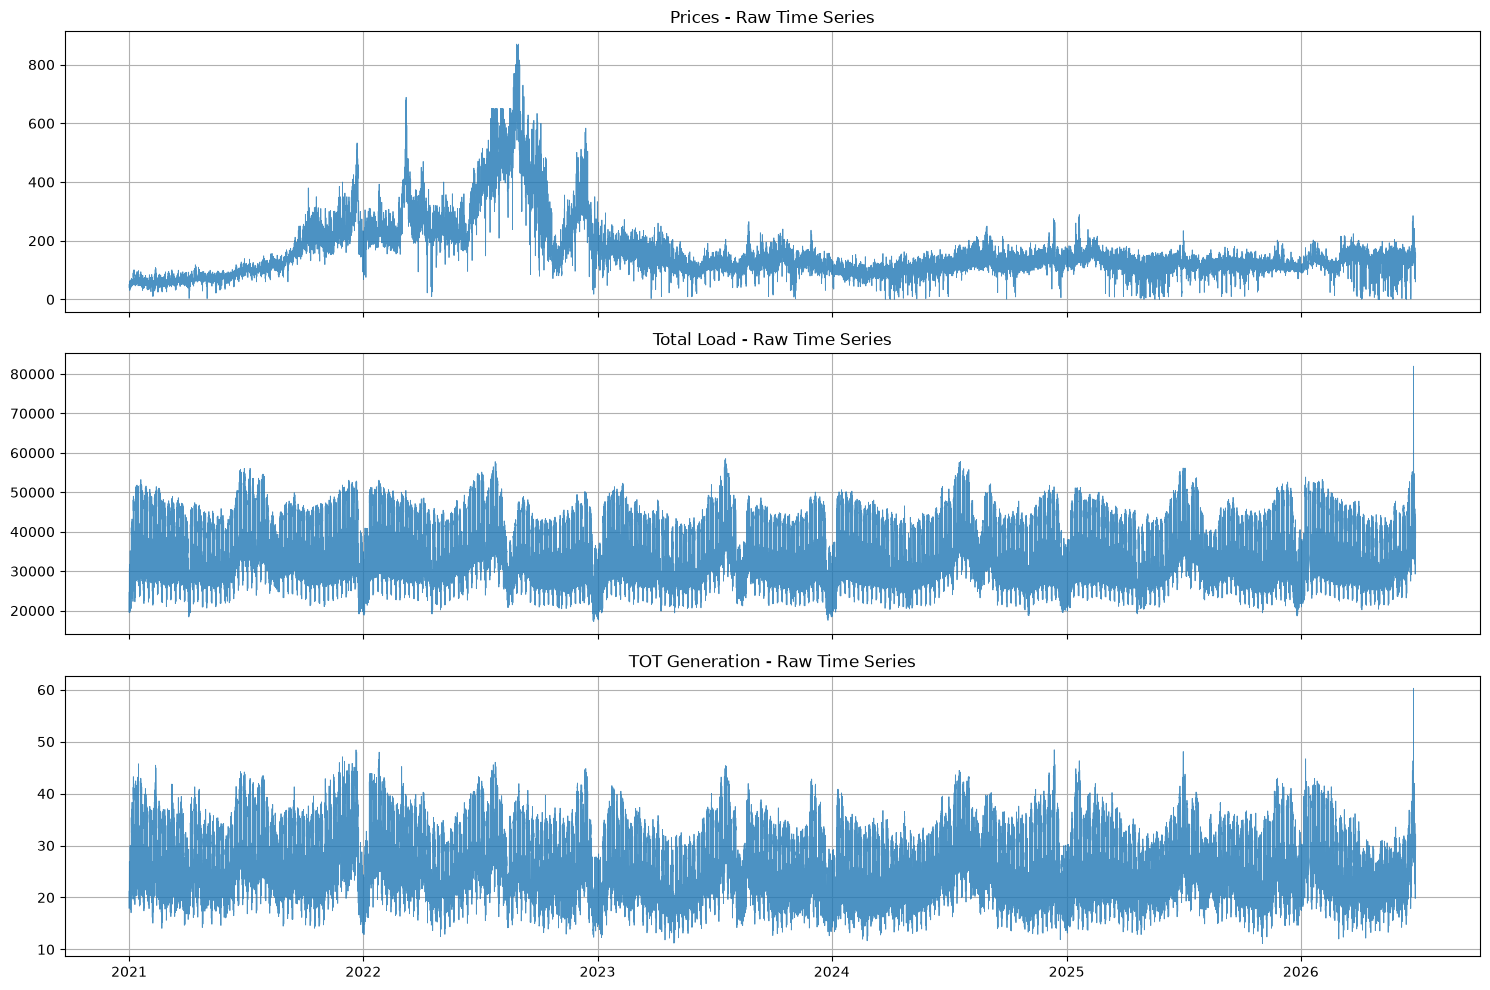

In [10]:
# import library
import matplotlib.pyplot as plt

# plot graph
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], linewidth=0.6, alpha=0.8)
    ax[i].set_title(f'{col} - Raw Time Series')
    ax[i].grid(True)

plt.tight_layout()
plt.show()

From this graph, it is noticeable how load and generation are highly correlated, while prices curve shows a peak during 2022 and unstability during the war time span. From 2023 the prices seem to be at normal level, with slight low spikes.

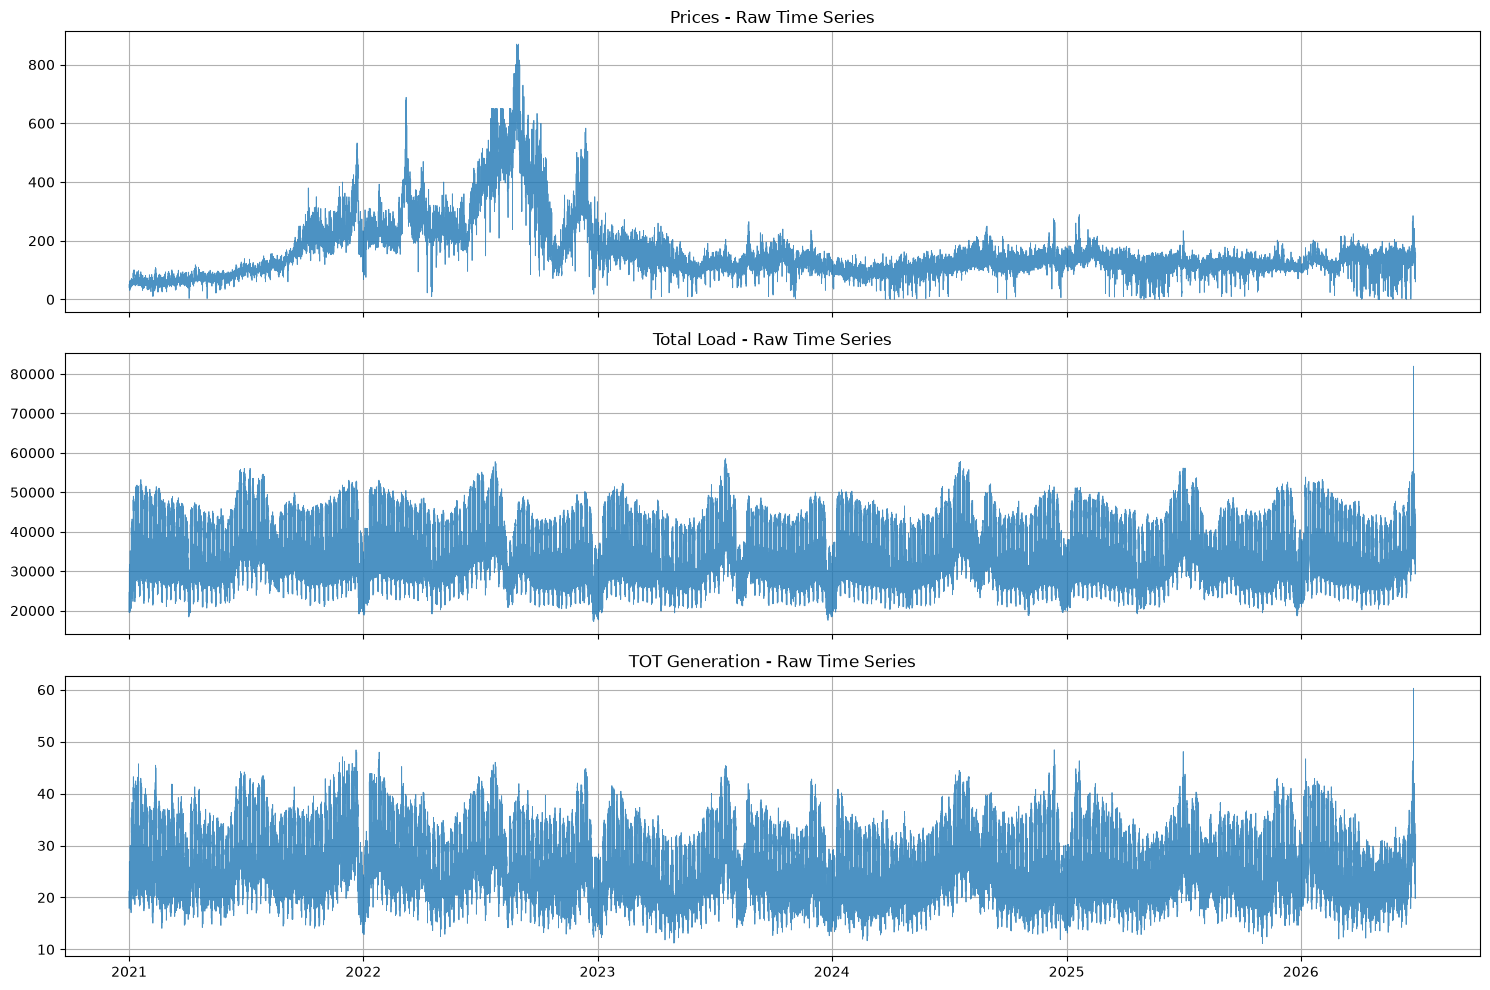

In [11]:
# import library
import matplotlib.pyplot as plt

# plot graph
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], linewidth=0.6, alpha=0.8)
    ax[i].set_title(f'{col} - Raw Time Series')
    ax[i].grid(True)

plt.tight_layout()
plt.show()

### 3.2. Rolling mean

To smooth short-term fluctuations in the hourly observations and highlight broader temporal patterns, a 24-hour rolling mean is calculated.

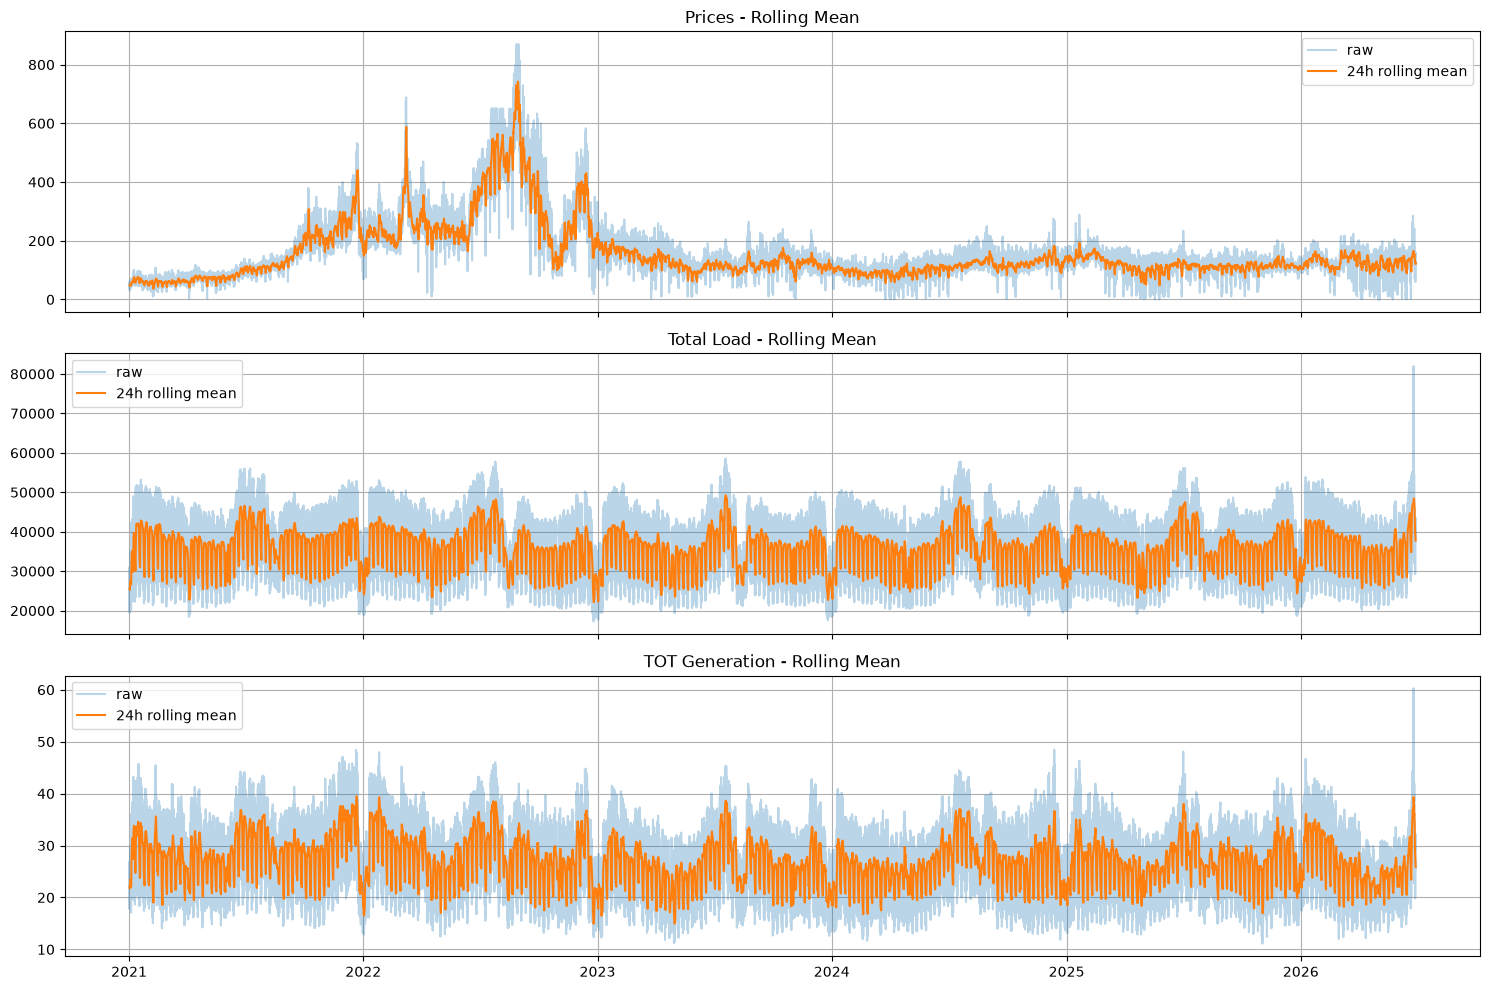

In [12]:
# define rolling window
window = 24  # 24h rolling window (1 day)

fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col], alpha=0.3, label='raw')
    ax[i].plot(data['Date'], data[col].rolling(window).mean(), label='24h rolling mean')
    ax[i].set_title(f'{col} - Rolling Mean')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

It is evident from the first graph of the rolling average **Prices** from 2021 to 2026 that, from the end of 2021 to the end of 2022, the Italian power price registered an unexpected and more growing increase, with a peak verified between Q3 and Q4 of 2022.  
The sharp increase in electricity prices observed during 2022 coincides with the European energy crisis following Russia's invasion of Ukraine and the disruption of Russian gas supplies to Europe.

Yearly Italian **Load** shows a dual-season pattern, typical of temperate-climate electricity systems, since in winter heating are needed and diffused while in summer cooling systems are needed.  
It is noticeable how in spring and autumn months there is less demand of energy, while a particular New-Years-Eve effect is observable, characterized by a yearly minimum load of energy. This could be related to Christmas, New Year's Eve and Epiphany holidays, in which often Italian tend to organize vacations abroad, while all commercial buildings are closed.

The **Generation** pattern seems to follow an yearly cycle, similar to the Load one.

### 3.3. Volatility of first differences Analysis

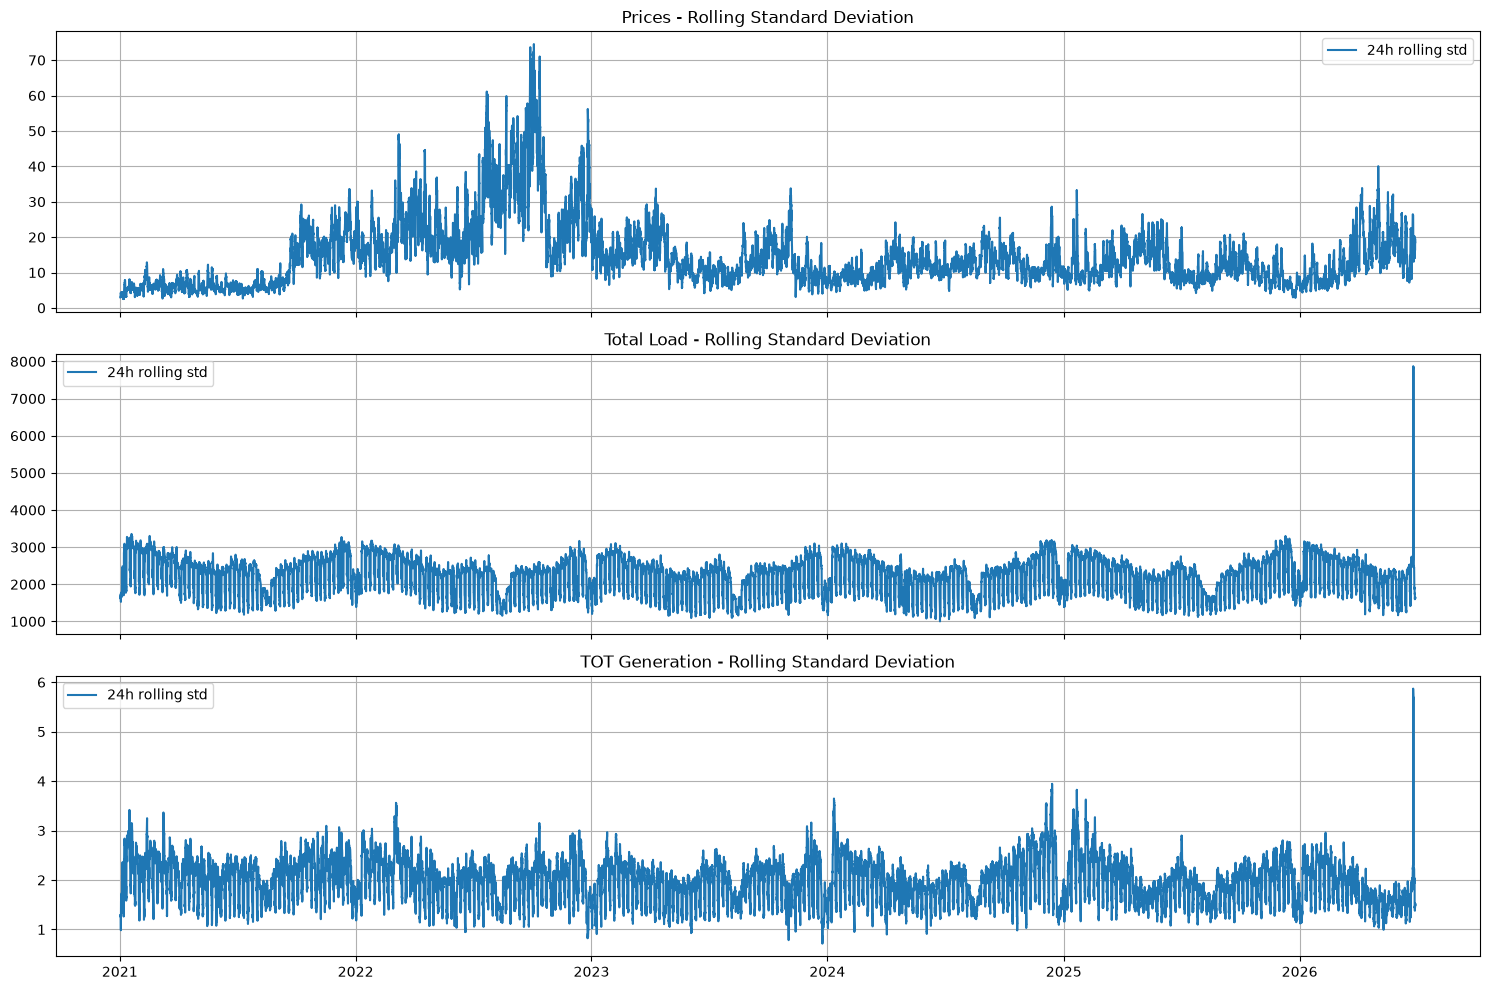

In [13]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, col in enumerate(cols):
    ax[i].plot(data['Date'], data[col].diff().rolling(window).std(), label='24h rolling std')
    ax[i].set_title(f'{col} - Rolling Standard Deviation')
    ax[i].legend()
    ax[i].grid(True)

plt.tight_layout()
plt.show()

While the rolling mean suggests a partial stabilization of price levels after the 2022 shock, rolling variability remains elevated during several subsequent periods.

Despite an apparently stabilization of prices after the Russian invasion, the volatility increased, which is consistent with:
* the expansion of renewables in the Italian power mix generation after the energy shock caused by the high dependecy from Russian gas imports;
* the increasing goepolitical risks associated with Middle East tensions.

**Generation** and **Load** have instead a similar pattern to the rolling mean graphs, which is explainadble by less volatility bounded by notable physical constraints.


### 3.4. Daily prices and major market events
To provide contextual interpretation of price dynamics over time, daily PUN prices are plotted together with major events identified by ACER as relevant to European electricity markets.

In [14]:
# convert hourly data in daily data
daily_prices = (
    data
    .set_index('Date')['Prices']
    .resample('D')
    .mean()
)

In [15]:
# create event DF
events = pd.DataFrame({
    'Date': pd.to_datetime([
        '2021-07-01',
        '2021-12-01',
        '2022-02-24',
        '2022-08-01',
        '2022-09-26',
        '2023-05-01',
        '2024-12-12',
        '2025-07-01',
        '2026-03-01'
    ]),
    
    'Event': [
        'Tight LNG supply',
        'Low hydro and nuclear availability',
        'Russian invasion of Ukraine',
        'Low wind and nuclear availability',
        'Nord Stream sabotage',
        'Gas TTF normalization phase',
        'Dunkelflaute',
        'European Heatwave',
        'Hormuz crisis'
    ],
    
    'Ticker': [
       'E1',
       'E2',
       'E3',
       'E4',
       'E5',
       'E6',
       'E7',
       'E8',
       'E9',
    ],
    
    'Category': [
        'Energy-system shock',
        'Energy-system shock',
        'Geopolitical - Supply shocks',
        'Energy-system shock',
        'Geopolitical - Supply shocks',
        'Regime transition',
        'Energy-system shock',
        'Energy-system shock',
        'Geopolitical - Supply shocks'
    ]
})

# define label positions
events['level'] = [0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05]

events

,Date,Event,Ticker,Category,level
0,2021-07-01,Tight LNG supply,E1,Energy-system shock,0.05
1,2021-12-01,Low hydro and nuclear availability,E2,Energy-system shock,0.05
2,2022-02-24,Russian invasion of Ukraine,E3,Geopolitical - Supply shocks,0.05
3,2022-08-01,Low wind and nuclear availability,E4,Energy-system shock,0.05
4,2022-09-26,Nord Stream sabotage,E5,Geopolitical - Supply shocks,0.05
5,2023-05-01,Gas TTF normalization phase,E6,Regime transition,0.05
6,2024-12-12,Dunkelflaute,E7,Energy-system shock,0.05
7,2025-07-01,European Heatwave,E8,Energy-system shock,0.05
8,2026-03-01,Hormuz crisis,E9,Geopolitical - Supply shocks,0.05


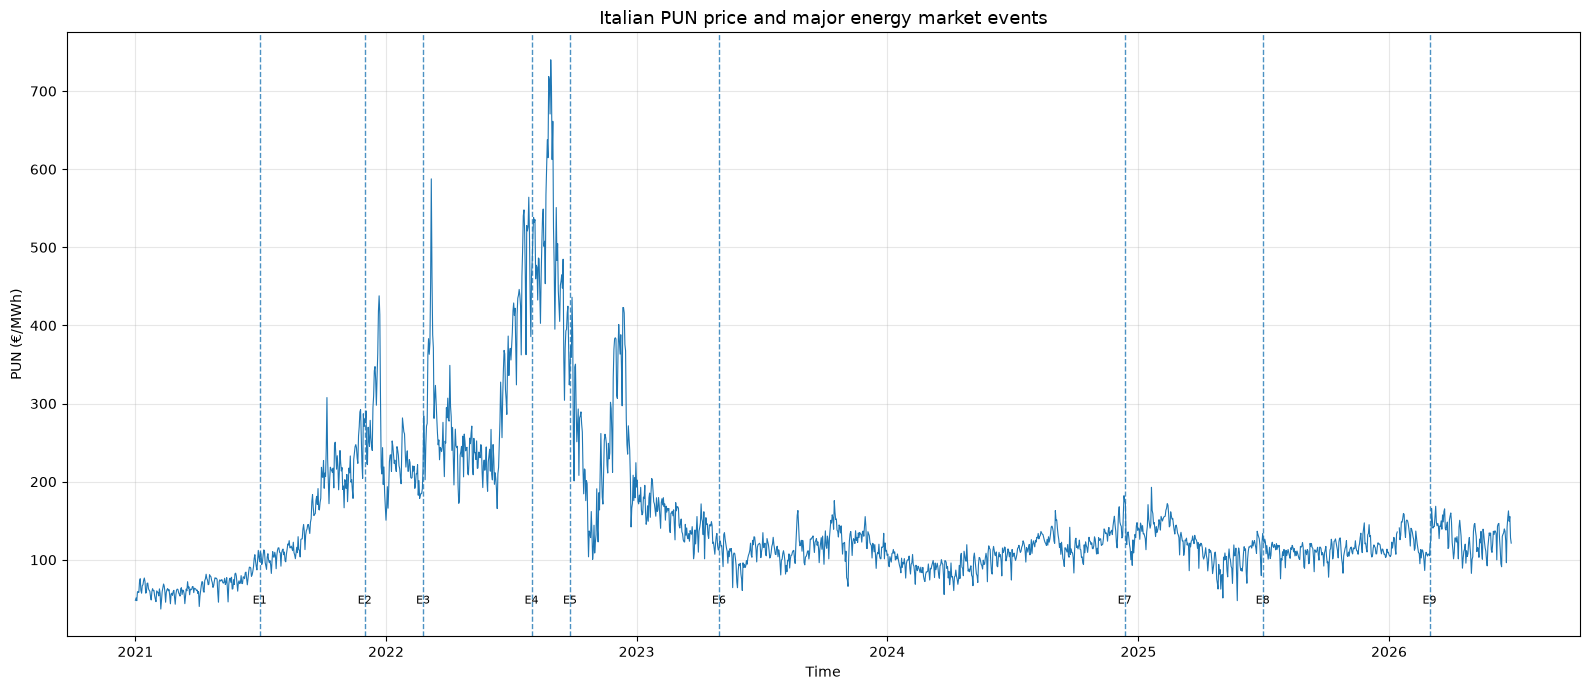

In [16]:
# display daily prices with significant events
fig, ax = plt.subplots(figsize=(16, 7))

# PUN time series
ax.plot(
    daily_prices.index,
    daily_prices.values,
    linewidth=0.8
)

# important events
for _, event in events.iterrows():
    # vertical line
    ax.axvline(
        event['Date'],
        linestyle='--',
        linewidth=1,
        alpha=0.8
    )

    # event label
    ax.text(
        event['Date'],
        event['level'],
        event['Ticker'],
        transform=ax.get_xaxis_transform(),
        rotation=0,
        ha='center',
        va='bottom',
        fontsize=8
    )

# labels and title
ax.set_title(
    'Italian PUN price and major energy market events',
    fontsize=13
)

ax.set_xlabel('Time')
ax.set_ylabel('PUN (€/MWh)')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Relationship analysis
Supply-demand interaction is crucial for determining the power spot markets prices determination.

### 4.1. Pearson correlation matrix

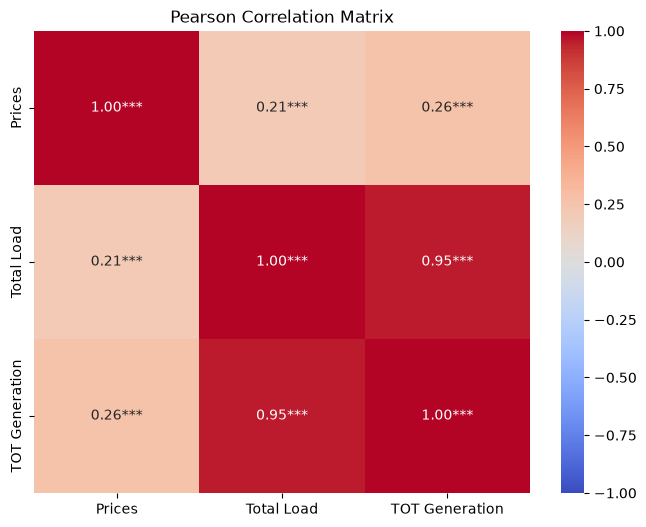

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

# correlation matrix
corr_matrix = data[cols].corr()

# P-value matrix
p_matrix = pd.DataFrame(
    index=cols,
    columns=cols,
    dtype=float
)

for col1 in cols:
    for col2 in cols:
        r, p = pearsonr(data[col1], data[col2])
        p_matrix.loc[col1, col2] = p

# create annotations
annotations = corr_matrix.copy().astype(str)

for row in cols:
    for col in cols:
        r = corr_matrix.loc[row, col]
        p = p_matrix.loc[row, col]

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        annotations.loc[row, col] = f'{r:.2f}{stars}'

# heatmap correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=annotations,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Pearson Correlation Matrix')
plt.show()

*p-value < 0.05  
**p-value < 0.01  
***p-value < 0.001  

Introducing **Renewables share** in Italian generation mix, negative correlation (-0.39) with prices is evident, indicating that higher renewable penetration is associated with lower electricity prices, consistent with merit-order effect.  
The relation between Renewables and Load being near to 0 indicates largely indipendence between the two variables, while 0.13 with Generation, indicates a structural mismatch between consumption and generation profiles.

Generation (**Supply**) and Load (proxy for **Demand**) are positively correlated, with a Pearson correlation coefficient of approximately 0.29, indicating partial coupling between demand and production, mediated by imports and market structure.



In [18]:
from scipy.stats import pearsonr
import pandas as pd

# p-value matrix
p_matrix = pd.DataFrame(
    index=cols,
    columns=cols,
    dtype=float
)

for col1 in cols:
    for col2 in cols:
        r, p = pearsonr(data[col1], data[col2])
        p_matrix.loc[col1, col2] = p
    
p_matrix

,Prices,Total Load,TOT Generation
Prices,0.0,0.0,0.0
Total Load,0.0,0.0,0.0
TOT Generation,0.0,0.0,0.0


To account for structural changes in the electricity market, the sample is divided into three distinct regimes: pre-2022, the 2022 shock period, and the post-2022 phase. This segmentation is motivated by the significant increase in price volatility observed during 2022, largely driven by the energy crisis and geopolitical tensions.

The scatterplots reveal that the relationship between prices and fundamental drivers such as load, generation, and renewable penetration is not stable over time. Instead, clear regime-dependent patterns emerge, with a visible structural break during 2022.

The exploratory analysis highlights a structurally segmented electricity market characterized by distinct pre- and post-2022 regimes. While demand remains relatively stable, prices exhibit high volatility and heavy-tailed distributions, suggesting strong exposure to external supply shocks.

The preliminary evidence indicates a negative association between renewable penetration and electricity prices, motivating a dedicated analysis of their relationship.

## 5. Renewable penetration and market regimes

In the previous exploratory data analysis, it has been found out the negative relationship between renewables shares and energy prices, expressed by the moderate negative correlation (-0.39).  
This indicated that higher renewable shares are associated with lower electricity prices.  
This association should not be interpreted as casual.

In [19]:
data.columns

Index(['Date', 'Prices', 'Geothermal', 'Hydro', 'Photovoltaic',
       'Self-consumption', 'Thermal', 'Wind', 'TOT Generation',
       'Renewables weight', 'Total Load', 'Load forecasted'],
      dtype='str')

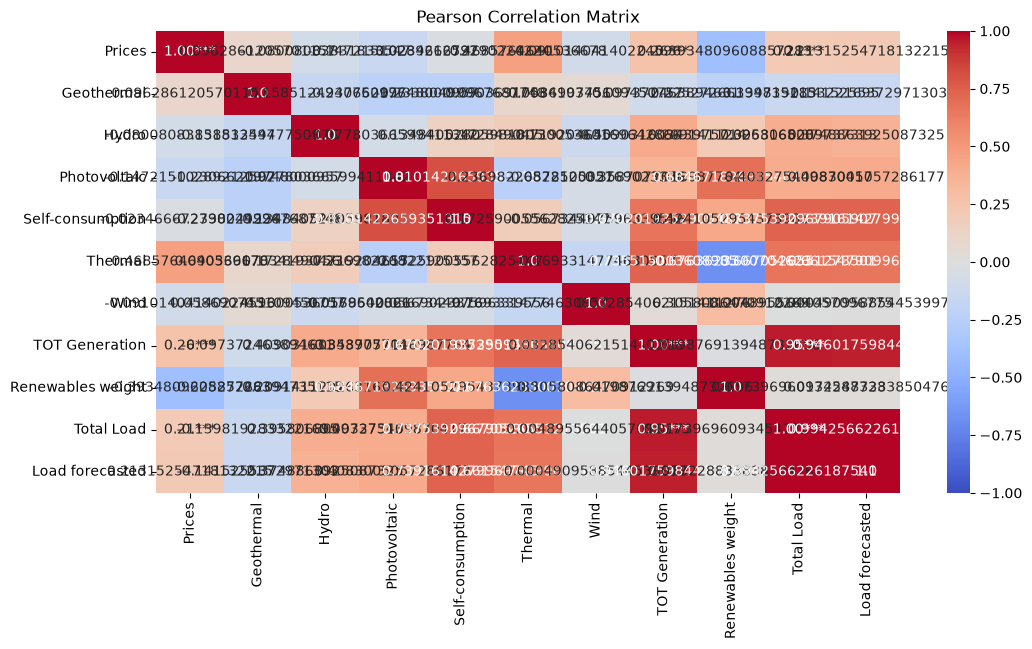

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

# correlation matrix
corr_matrix = data[data.columns].corr(numeric_only=True)

# p-value matrix
p_matrix = pd.DataFrame(
    index=cols,
    columns=cols,
    dtype=float
)

for col1 in cols:
    for col2 in cols:
        r, p = pearsonr(data[col1], data[col2])
        p_matrix.loc[col1, col2] = p

# create annotations
annotations = corr_matrix.copy().astype(str)

for row in cols:
    for col in cols:
        r = corr_matrix.loc[row, col]
        p = p_matrix.loc[row, col]

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        annotations.loc[row, col] = f'{r:.2f}{stars}'

# heatmap correlation matrix
plt.figure(figsize=(12, 6))

sns.heatmap(
    corr_matrix,
    annot=annotations,
    fmt='',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Pearson Correlation Matrix')
plt.show()

In [21]:
corr_matrix

,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
Prices,1.000000,0.096286,-0.080081,-0.147215,-0.023467,0.468576,-0.091014,0.264976,-0.393481,0.207378,0.213153
Geothermal,0.096286,1.000000,-0.158512,-0.230662,-0.233805,0.090369,0.058691,-0.097372,-0.225273,-0.139819,-0.141526
Hydro,-0.080081,-0.158512,1.000000,-0.077804,0.134841,0.172849,-0.130054,0.409032,0.209141,0.395807,0.374886
Photovoltaic,-0.147215,-0.230662,-0.077804,1.000000,0.810142,-0.236982,-0.057850,0.358708,0.684672,0.403275,0.408301
Self-consumption,-0.023467,-0.233805,0.134841,0.810142,1.000000,0.172590,-0.056734,0.670202,0.424105,0.737539,0.739161
Thermal,0.468576,0.090369,0.172849,-0.236982,0.172590,1.000000,-0.169331,0.735515,-0.676362,0.667053,0.661548
Wind,-0.091014,0.058691,-0.130054,-0.057850,-0.056734,-0.169331,1.000000,0.032854,0.305809,-0.004896,0.000491
TOT Generation,0.264976,-0.097372,0.409032,0.358708,0.670202,0.735515,0.032854,1.000000,-0.019877,0.953476,0.946018
Renewables weight,-0.393481,-0.225273,0.209141,0.684672,0.424105,-0.676362,0.305809,-0.019877,1.000000,0.017397,0.017229
Total Load,0.207378,-0.139819,0.395807,0.403275,0.737539,0.667053,-0.004896,0.953476,0.017397,1.000000,0.994257


To further investigate the relationship about these two variable, a linear regression study is applied in order to find out more precisely how muche these variations happpen.

### 5.1 Bivariate relationship between renewable penetration and prices

In [22]:
# rename Renewables weight for linear regression model
data = data.rename(
    columns={'Renewables weight': 'Renewables_weight'}
)

data.head()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000


#### 5.1.1. Model implementation

In [23]:
# model variables
VAR_X = 'Renewables_weight'
VAR_Y = 'Prices'

formula = f'{VAR_Y} ~ {VAR_X}'

model = smf.ols(formula, data=data).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2021 - 2026)\n')
print(model.summary())


Linear Regression Model - Prices and Renewables (2021 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     8804.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:20:51   Log-Likelihood:            -2.8590e+05
No. Observations:               48060   AIC:                         5.718e+05
Df Residuals:                   48058   BIC:                         5.718e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [24]:
# get params for line equation
params = model.params

# x values
ax_x = 'Renewables_weight'
x = np.linspace(0, 1, 100)

# coefficients
b0 = model.params['Intercept']
b1 = model.params['Renewables_weight']

# f lines
y_d_0 = b0 + b1 * x 


In [43]:
fig = px.scatter(
    data, 
    x='Renewables_weight', 
    y='Prices', 
    hover_data={
        'Renewables_weight': True,
        'Prices': True, 
        'Date': True
    }, 
    opacity=0.05
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_0,
        mode='lines',
        name='Power Prices',
        line=dict(width=4)
    )
)

fig.update_layout(
    title='Linear Regression (OLS)',
    xaxis_title='Renewables share',
    yaxis_title='Prices',
    template='simple_white'
)

fig.show()

#### 5.1.2. Model evaluation

Before commenting the regression results, it is necessary to execute basic tests on:
1. Heteroscedasticity
2. Autocorrelation of the residuals

##### 1. Heteroscedasticity - Breusch-Pagan test


In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan test
bp_test = het_breuschpagan(
    model.resid,
    model.model.exog
)

bp_labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print('\nBreusch-Pagan Test')
for label, value in zip(bp_labels, bp_test):
    print(f'{label}: {value:.4f}')


Breusch-Pagan Test
LM Statistic: 1431.6570
LM p-value: 0.0000
F Statistic: 1475.5526
F p-value: 0.0000


p-value < 0.05 indicates that the null hypothesis (homoschedasticity) is refused and therefore, that there is evidence of heteroscedasticity.

##### 2. Residuals Autocorrelation

In [27]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# Breusch-Godfrey test
bg_test = acorr_breusch_godfrey(
    model,
    nlags=24    # 24 hrs lag correlation
)

bg_labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print('\nBreusch-Godfrey Test')
for label, value in zip(bg_labels, bg_test):
    print(f'{label}: {value:.4f}')


Breusch-Godfrey Test
LM Statistic: 46953.7833
LM p-value: 0.0000
F Statistic: 84950.8788
F p-value: 0.0000


H0: no autocorrelation until the lag taken into consideration  
vs  
H1: autocorrelation

p-value < 0.05 indicates the residuals autocorrelation.


In [28]:
# Durbin-Watson test check
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model.resid)

print(f'\nDurbin-Watson statistic: {dw:.4f}')


Durbin-Watson statistic: 0.0400


Durbin-Watson value 0.04 < 2 indicates a strong positive autocorrelation of the residuals. This result is consistent with former Breusch-Godfrey test which confirms autocorrelation.

Having these results about the former linear regression model, the same model is displayed with HAC covariance in ordere to have more accurate data on standard errores and significance of the coefficients.

#### 5.1.3. Model correction

In [29]:
# hac model
bivariate_hac_model = smf.ols(
    formula, 
    data=data
).fit(
    cov_type='HAC', 
    cov_kwds={
        'maxlags':24
    }
)

print(f'\nLinear Regression Model - Prices and Renewables (2021 - 2026)\n')
print(bivariate_hac_model.summary())


Linear Regression Model - Prices and Renewables (2021 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.155
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     752.7
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.98e-164
Time:                        14:21:27   Log-Likelihood:            -2.8590e+05
No. Observations:               48060   AIC:                         5.718e+05
Df Residuals:                   48058   BIC:                         5.718e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

### 5.2. Regime-dependent relationship

In [30]:
# define market regimes
data['Regime'] = np.where(data['Date'] < '2022-01-01', 'Pre-2022',
                   np.where(data['Date'] < '2023-01-01', '2022 Shock', 'Post-2022'))

pre_2022 = data[data['Regime'] == 'Pre-2022'] 
during_2022 = data[data['Regime'] == '2022 Shock'] 
post_2022 = data[data['Regime'] == 'Post-2022']

data.head()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted,Regime
0,2021-01-01 00:00:00,50.87000,0.62,3.43,0.0,2.058,14.55,2.60,21.20,0.313679,24640.25075,24614.24975,Pre-2022
1,2021-01-01 01:00:00,48.19000,0.62,3.03,0.0,1.952,13.68,2.75,20.08,0.318725,22909.00000,23971.99975,Pre-2022
2,2021-01-01 02:00:00,44.67966,0.62,2.79,0.0,1.812,12.77,2.63,18.81,0.321106,21044.49975,22554.74950,Pre-2022
3,2021-01-01 03:00:00,42.92193,0.62,2.60,0.0,1.735,12.12,2.62,17.96,0.325167,19907.99975,21153.49975,Pre-2022
4,2021-01-01 04:00:00,40.39151,0.62,2.60,0.0,1.733,12.06,2.61,17.89,0.325880,19578.49950,20336.75000,Pre-2022


#### 5.2.1. Model implementation

In [31]:
# interaction
regime_interaction_model = smf.ols(
    'Prices ~ Renewables_weight * Regime',
    data=data
).fit()

print(regime_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                 1.142e+04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:21:38   Log-Likelihood:            -2.7112e+05
No. Observations:               48060   AIC:                         5.422e+05
Df Residuals:                   48054   BIC:                         5.423e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

#### 5.2.2. Model evaluation

This model will be evaluated by: 
1. Heteroscedasticity
2. Residuals autocorrelation
3. Multicollinearity

##### 1. Heteroscedasticity

In [32]:
# Breusch-Pagan test
bp_test = het_breuschpagan(
    regime_interaction_model.resid,
    regime_interaction_model.model.exog
)

bp_labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print('\nBreusch-Pagan Test')
for label, value in zip(bp_labels, bp_test):
    print(f'{label}: {value:.4f}')


Breusch-Pagan Test
LM Statistic: 8962.8817
LM p-value: 0.0000
F Statistic: 2203.2433
F p-value: 0.0000


#### 2. Residuals autocorrelation

In [33]:
# Breusch-Godfrey test
bg_test = acorr_breusch_godfrey(
    regime_interaction_model,
    nlags=24    # 24 hrs lag correlation
)

bg_labels = [
    'LM Statistic',
    'LM p-value',
    'F Statistic',
    'F p-value'
]

print('\nBreusch-Godfrey Test')
for label, value in zip(bg_labels, bg_test):
    print(f'{label}: {value:.4f}')


Breusch-Godfrey Test
LM Statistic: 46216.5354
LM p-value: 0.0000
F Statistic: 50172.2900
F p-value: 0.0000


In [34]:
# Durbin-Watson test check
dw = durbin_watson(regime_interaction_model.resid)

print(f'\nDurbin-Watson statistic: {dw:.4f}')


Durbin-Watson statistic: 0.0666


#### 3. Multicollinearity

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = regime_interaction_model.model.exog
feature_names = regime_interaction_model.model.exog_names

vif = pd.DataFrame({
    'Variable': feature_names,
    'VIF': [
        variance_inflation_factor(X, i)
        for i in range(X.shape[1])
    ]
})

print('\nVariance Inflation Factors')
print(vif)


Variance Inflation Factors
                                Variable        VIF
0                              Intercept   1.000000
1                    Regime[T.Post-2022]  12.744460
2                     Regime[T.Pre-2022]  15.500452
3                      Renewables_weight   8.696896
4  Renewables_weight:Regime[T.Post-2022]  26.103981
5   Renewables_weight:Regime[T.Pre-2022]  17.771819


The model shows high VIF (Variance Inflation Factor) values for some variables, especially fotr the inteaction ones.  
However these values should be interpreted in reason of the costruction of the model, since the interactive variables had been built from the main regressors and regime dummies.  

Estimating spearatively those coefficients is less precise since some variables contains opposites information.

### 5.2.3. Model correction

In [48]:
# robust model to heteroskedasticity and autocorrelation
regime_robust_model = smf.ols(
    'Prices ~ Renewables_weight * Regime',
    data=data
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':24}
)

print(regime_robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     543.8
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:57:06   Log-Likelihood:            -2.7112e+05
No. Observations:               48060   AIC:                         5.422e+05
Df Residuals:                   48054   BIC:                         5.423e+05
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [49]:
# model params for visualization
params = regime_robust_model.params

# x values
x = np.linspace(
    data['Renewables_weight'].min(),
    data['Renewables_weight'].max(),
    100
)

# coefficients
b0 = regime_robust_model.params['Intercept']
b1 = regime_robust_model.params['Renewables_weight']
b2 = regime_robust_model.params['Regime[T.Post-2022]']
b3 = regime_robust_model.params['Regime[T.Pre-2022]']
b4 = regime_robust_model.params['Renewables_weight:Regime[T.Post-2022]']
b5 = regime_robust_model.params['Renewables_weight:Regime[T.Pre-2022]']

# f lines
y_shock = b0 + b1 * x
y_post = b0 + b1 * x + b2 + b4 * x
y_pre = b0 + b1 * x + b3 + b5 * x

In [44]:
# extensions of x to see what happens when renewables is 0% and 100%
x_ext = np.linspace(0, 1, 100)

fig = px.scatter(
    data,
    x='Renewables_weight',
    y='Prices',
    color='Regime',
    trendline='ols', 
    opacity=0.05
)

results = px.get_trendline_results(fig)

for _, row in results.iterrows():
    regime = row['Regime']
    regime_robust_model = row['px_fit_results']

    intercept = regime_robust_model.params[0]
    slope = regime_robust_model.params[1]

    y_ext = intercept + slope * x_ext

    fig.add_trace(
        go.Scatter(
            x=x_ext,
            y=y_ext,
            mode='lines',
            name=f'{regime} extension',
            line=dict(
                dash='dash',
                width=2
            ),
            hovertemplate=(
                f'Regime: {regime}<br>'
                'Renewables: %{x:.2f}<br>'
                'Predicted Price: %{y:.2f}'
                '<extra></extra>'
            )
        )
    )

fig.add_vline(
    x=0,
    line_dash='dot',
    line_color='black'
)